# **Data**

In [ ]:
import pandas as pd

In [ ]:
df_adult=pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_adult

In [ ]:
df_youth=pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_youth

In [ ]:
df_illiteracy =pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_illiteracy

In [ ]:
df_gdp =pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_gdp

In [ ]:
df_avg_year_schooling =pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_avg_year_schooling

# **merge table**

In [ ]:
df_literacy = pd.merge(df_adult,df_youth,on=["entity","code","year"],how="left")
df_literacy

In [ ]:
df_illiteracy =df_illiteracy
df_illiteracy

In [ ]:
df_gdp_schooling =pd.merge(df_gdp,df_avg_year_schooling,on=["entity","code","year","owid_region"],how="left")
df_gdp_schooling


# **handling missing values**

In [ ]:
#df_literacy

In [ ]:
df_literacy.isnull().sum()

,0
entity,0
code,0
year,0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,0
youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,0
youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,0
owid_region,0


In [ ]:
df_literacy["youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m"] = \
df_literacy.groupby("entity")["youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m"] \
.transform(lambda x: x.fillna(x.mean()))

In [ ]:
df_literacy["youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m"].isnull().sum()

np.int64(4)

In [ ]:
df_literacy = df_literacy.dropna(subset=["youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m","youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f"])

In [ ]:
df_literacy["youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f"] = \
df_literacy.groupby("entity")["youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f"] \
.transform(lambda x: x.fillna(x.mean()))

/tmp/ipykernel_397/3426634437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy["youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f"] = \


In [ ]:
df_literacy["owid_region"].unique()

array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
       'South America', nan], dtype=object)

In [ ]:
df_literacy[df_literacy["owid_region"].isnull()]["entity"].unique()

array(['Central and Southern Asia (SDG)', 'East Asia and Pacific (WB)',
       'Eastern and South-Eastern Asia (SDG)',
       'Europe and Central Asia (WB)',
       'Europe and Northern America (SDG)',
       'Latin America and Caribbean (WB)',
       'Latin America and the Caribbean (SDG)', 'Low-income countries',
       'Lower-middle-income countries',
       'Middle East and North Africa (WB)', 'Middle-income countries',
       'North America (WB)', 'Northern Africa and Western Asia (SDG)',
       'Oceania (excluding Australia and New Zealand) (SDG)',
       'South Asia (WB)', 'Sub-Saharan Africa (SDG)',
       'Sub-Saharan Africa (WB)', 'Upper-middle-income countries',
       'World'], dtype=object)

In [ ]:
region_map = {
    "Central and Southern Asia (SDG)": "Asia",
    "East Asia and Pacific (WB)": "Asia",
    "Eastern and South-Eastern Asia (SDG)": "Asia",
    "South Asia (WB)": "Asia",
    "Iran": "Asia",

    "Europe and Central Asia (WB)": "Europe",
    "Europe and Northern America (SDG)": "Europe",

    "Middle East and North Africa (WB)": "Africa",
    "Northern Africa and Western Asia (SDG)": "Africa",
    "Sub-Saharan Africa (SDG)": "Africa",
    "Sub-Saharan Africa (WB)": "Africa",
    "Mali": "Africa",
    "Morocco": "Africa",
    "Rwanda": "Africa",

    "Latin America and Caribbean (WB)": "South America",
    "Latin America and the Caribbean (SDG)": "South America",
    "Cuba": "North America",

    "North America (WB)": "North America",

    "Oceania (excluding Australia and New Zealand) (SDG)": "Oceania",
    "Vanuatu": "Oceania",

    "Low-income countries": "Africa",
    "Lower-middle-income countries": "Asia",
    "Middle-income countries": "Asia",
    "Upper-middle-income countries": "Asia",

    "Mauritius": "Africa",

    "World": "World"
}

In [ ]:
df_literacy["owid_region"] = df_literacy["owid_region"].fillna(
    df_literacy["entity"].map(region_map)
)

/tmp/ipykernel_397/2174107424.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy["owid_region"] = df_literacy["owid_region"].fillna(


In [ ]:
df_literacy = df_literacy.dropna(subset =["owid_region"])

In [ ]:
df_literacy["code"].unique()

array(['AFG', 'ALB', 'DZA', 'ASM', 'AGO', 'AIA', 'ARG', 'ARM', 'ABW',
       'AZE', 'BHR', 'BGD', 'BRB', 'BLR', 'BLZ', 'BEN', 'BTN', 'BOL',
       'BIH', 'BWA', 'BRA', 'BRN', 'BGR', 'BFA', 'BDI', 'KHM', 'CMR',
       'CPV', 'CYM', 'CAF', nan, 'TCD', 'CHL', 'CHN', 'COL', 'COM', 'COG',
       'CRI', 'CIV', 'HRV', 'CUB', 'CYP', 'COD', 'DOM', 'TLS', 'ECU',
       'EGY', 'SLV', 'GNQ', 'ERI', 'EST', 'SWZ', 'ETH', 'GAB', 'GMB',
       'GEO', 'GHA', 'GRC', 'GRD', 'GLP', 'GUM', 'GTM', 'GIN', 'GNB',
       'GUY', 'HTI', 'HND', 'HUN', 'IND', 'IDN', 'IRN', 'IRQ', 'ISR',
       'ITA', 'JAM', 'JOR', 'KAZ', 'KEN', 'KIR', 'KWT', 'KGZ', 'LAO',
       'LVA', 'LBN', 'LSO', 'LBR', 'LBY', 'LTU', 'MAC', 'MDG', 'MWI',
       'MYS', 'MDV', 'MLI', 'MLT', 'MHL', 'MTQ', 'MRT', 'MUS', 'MEX',
       'MDA', 'MNG', 'MNE', 'MAR', 'MOZ', 'MMR', 'NAM', 'NPL', 'NCL',
       'NIC', 'NER', 'NGA', 'PRK', 'MKD', 'OMN', 'PAK', 'PLW', 'PSE',
       'PAN', 'PNG', 'PRY', 'PER', 'PHL', 'POL', 'PRT', 'PRI', 'QAT',
       'REU', '

In [ ]:
df_literacy[df_literacy["code"].isnull()]["entity"].unique()

array(['Central and Southern Asia (SDG)', 'East Asia and Pacific (WB)',
       'Eastern and South-Eastern Asia (SDG)',
       'Europe and Central Asia (WB)',
       'Europe and Northern America (SDG)',
       'Latin America and Caribbean (WB)',
       'Latin America and the Caribbean (SDG)', 'Low-income countries',
       'Lower-middle-income countries',
       'Middle East and North Africa (WB)', 'Middle-income countries',
       'North America (WB)', 'Northern Africa and Western Asia (SDG)',
       'Oceania (excluding Australia and New Zealand) (SDG)',
       'South Asia (WB)', 'Sub-Saharan Africa (SDG)',
       'Sub-Saharan Africa (WB)', 'Upper-middle-income countries'],
      dtype=object)

In [ ]:
region_code_map = {
    "Central and Southern Asia (SDG)": "CSA",
    "East Asia and Pacific (WB)": "EAP",
    "Eastern and South-Eastern Asia (SDG)": "ESEA",
    "Europe and Central Asia (WB)": "ECA",
    "Europe and Northern America (SDG)": "ENA",
    "Latin America and Caribbean (WB)": "LAC",
    "Latin America and the Caribbean (SDG)": "LAC",
    "Middle East and North Africa (WB)": "MENA",
    "North America (WB)": "NA",
    "Northern Africa and Western Asia (SDG)": "NAWA",
    "Oceania (excluding Australia and New Zealand) (SDG)": "OCE",
    "South Asia (WB)": "SA",
    "Sub-Saharan Africa (SDG)": "SSA",
    "Sub-Saharan Africa (WB)": "SSA",

    "Low-income countries": "LIC",
    "Lower-middle-income countries": "LMIC",
    "Middle-income countries": "MIC",
    "Upper-middle-income countries": "UMIC"
}

In [ ]:
df_literacy["code"] = df_literacy["code"].fillna(
    df_literacy["entity"].map(region_code_map))

In [ ]:
# df_illiteracy

In [ ]:
df_illiteracy.isnull().sum()

,0
entity,0
code,0
year,0
illiteracy_rate,0
literacy_rate,0


In [ ]:
region_code_map = {
    "Central and Southern Asia (SDG)": "CSA",
    "East Asia and Pacific (WB)": "EAP",
    "Eastern and South-Eastern Asia (SDG)": "ESEA",
    "Europe and Central Asia (WB)": "ECA",
    "Europe and Northern America (SDG)": "ENA",
    "Latin America and Caribbean (WB)": "LAC",
    "Latin America and the Caribbean (SDG)": "LAC",
    "Middle East and North Africa (WB)": "MENA",
    "North America (WB)": "NA",
    "Northern Africa and Western Asia (SDG)": "NAWA",
    "Oceania (excluding Australia and New Zealand) (SDG)": "OCE",
    "South Asia (WB)": "SA",
    "Sub-Saharan Africa (SDG)": "SSA",
    "Sub-Saharan Africa (WB)": "SSA",

    "Low-income countries": "LIC",
    "Lower-middle-income countries": "LMIC",
    "Middle-income countries": "MIC",
    "Upper-middle-income countries": "UMIC"
}

In [ ]:
df_illiteracy["code"] = df_illiteracy["code"].fillna(
    df_illiteracy["entity"].map(region_code_map))

In [ ]:
df_illiteracy["code"].isnull().sum()

np.int64(4)

In [ ]:
df_illiteracy = df_illiteracy.dropna(subset=["code"])

In [ ]:
# df_gdp_schooling

In [ ]:
df_gdp_schooling.isnull().sum()

,0
entity,0
code,0
year,0
ny_gdp_pcap_pp_kd,0
owid_region,0
literacy_rate,0
mf_youth_and_adults__15_64_years__average_years_of_education,0
population_historical,0


In [ ]:
df_gdp_schooling["literacy_rate"] = \
df_gdp_schooling.groupby("entity")["literacy_rate"] \
.transform(lambda x: x.fillna(x.mean()))

In [ ]:
df_gdp_schooling["mf_youth_and_adults__15_64_years__average_years_of_education"] = \
df_gdp_schooling.groupby("entity")["mf_youth_and_adults__15_64_years__average_years_of_education"] \
.transform(lambda x: x.fillna(x.mean()))

In [ ]:
df_gdp_schooling["population_historical"] = \
df_gdp_schooling.groupby("entity")["population_historical"] \
.transform(lambda x: x.fillna(x.mean()))

In [ ]:
region_map = {
    "Central and Southern Asia (SDG)": "Asia",
    "East Asia and Pacific (WB)": "Asia",
    "Eastern and South-Eastern Asia (SDG)": "Asia",
    "South Asia (WB)": "Asia",
    "Iran": "Asia",

    "Europe and Central Asia (WB)": "Europe",
    "Europe and Northern America (SDG)": "Europe",

    "Middle East and North Africa (WB)": "Africa",
    "Northern Africa and Western Asia (SDG)": "Africa",
    "Sub-Saharan Africa (SDG)": "Africa",
    "Sub-Saharan Africa (WB)": "Africa",
    "Mali": "Africa",
    "Morocco": "Africa",
    "Rwanda": "Africa",

    "Latin America and Caribbean (WB)": "South America",
    "Latin America and the Caribbean (SDG)": "South America",
    "Cuba": "North America",

    "North America (WB)": "North America",

    "Oceania (excluding Australia and New Zealand) (SDG)": "Oceania",
    "Vanuatu": "Oceania",

    "Low-income countries": "Africa",
    "Lower-middle-income countries": "Asia",
    "Middle-income countries": "Asia",
    "Upper-middle-income countries": "Asia",

    "Mauritius": "Africa",

    "World": "World"
}

In [ ]:
df_gdp_schooling["owid_region"] = df_gdp_schooling["owid_region"].fillna(
    df_gdp_schooling["entity"].map(region_map)
)

In [ ]:
df_gdp_schooling = df_gdp_schooling.dropna(subset=["owid_region","literacy_rate","mf_youth_and_adults__15_64_years__average_years_of_education","population_historical"])


# **Remove duplicates**

In [ ]:
df_literacy[df_literacy.duplicated()].sum()

,0
entity,0
code,0
year,0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,0.0
youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,0.0
youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,0.0
owid_region,0


In [ ]:
df_illiteracy[df_illiteracy.duplicated()].sum()

,0
entity,0
code,0
year,0
illiteracy_rate,0.0
literacy_rate,0.0


In [ ]:
df_gdp_schooling[df_gdp_schooling.duplicated()].sum()

,0
entity,0
code,0
year,0
ny_gdp_pcap_pp_kd,0.0
owid_region,0
literacy_rate,0.0
mf_youth_and_adults__15_64_years__average_years_of_education,0.0
population_historical,0.0


# **Standardize country names**

In [ ]:
df_literacy["entity"] = df_literacy["entity"].str.strip()

In [ ]:
df_illiteracy["entity"] =df_illiteracy["entity"].str.strip()

/tmp/ipykernel_397/917018161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_illiteracy["entity"] =df_illiteracy["entity"].str.strip()


In [ ]:
df_gdp_schooling["entity"] =df_gdp_schooling["entity"].str.strip()

/tmp/ipykernel_397/310480906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling["entity"] =df_gdp_schooling["entity"].str.strip()


# **shape and structure**

In [ ]:
df_literacy.shape

(1708, 7)

In [ ]:
df_literacy.columns

Index(['entity', 'code', 'year',
       'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99',
       'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m',
       'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f',
       'owid_region'],
      dtype='object')

In [ ]:
df_illiteracy.shape

(2055, 5)

In [ ]:
df_illiteracy.columns

Index(['entity', 'code', 'year', 'illiteracy_rate', 'literacy_rate'], dtype='object')

In [ ]:
df_gdp_schooling.shape

(3901, 8)

In [ ]:
df_gdp_schooling.columns

Index(['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region',
       'literacy_rate',
       'mf_youth_and_adults__15_64_years__average_years_of_education',
       'population_historical'],
      dtype='object')

# **Identify any unusual values**

In [ ]:
df_literacy.describe()

,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f
count,1708.000000,1708.000000,1708.000000,1708.000000
mean,2003.856557,77.337579,89.016848,83.591187
std,13.192679,19.312535,12.667570,19.246105
min,1970.000000,9.000000,22.000000,7.000000
25%,1994.000000,64.441170,82.819005,72.948222
50%,2007.000000,82.143840,94.000000,92.000000
75%,2015.000000,94.000000,98.479942,98.835233
max,2023.000000,100.000000,100.000000,100.000000


In [ ]:
df_illiteracy.describe()

,year,illiteracy_rate,literacy_rate
count,2055.000000,2055.000000,2055.000000
mean,1986.823844,27.322500,72.677500
std,61.665477,24.403462,24.403462
min,1475.000000,0.000000,0.000000
25%,1983.000000,6.643055,58.000000
50%,2002.000000,20.912750,79.087250
75%,2013.000000,42.000000,93.356945
max,2023.000000,100.000000,100.000000


In [ ]:
df_gdp_schooling.describe()

,year,ny_gdp_pcap_pp_kd,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical
count,3901.000000,3901.000000,3901.000000,3901.000000,3.901000e+03
mean,2007.034094,17264.752690,82.126437,7.723974,4.828478e+07
std,10.075770,21684.300851,17.744840,2.682486,1.669614e+08
min,1990.000000,510.822800,14.000000,0.950000,1.002940e+05
25%,1998.000000,4070.612300,71.400000,5.718571,3.368022e+06
50%,2007.000000,10035.056000,90.222222,7.898571,1.031300e+07
75%,2016.000000,20147.710000,96.000000,10.002857,3.181572e+07
max,2024.000000,174569.520000,100.000000,13.680000,1.438070e+09


# **Rename columns**

In [ ]:
df_literacy.columns

Index(['entity', 'code', 'year',
       'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99',
       'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m',
       'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f',
       'owid_region'],
      dtype='object')

In [ ]:
df_literacy = df_literacy.rename(columns={"entity":"Country",
                                          "adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99":"Adult_literacy",
                                          "youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m":"Male_literacy",
                                          "youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f":"Female_literacy",
                                          "owid_region":"Region"})

In [ ]:
df_literacy

,Country,code,year,Adult_literacy,Male_literacy,Female_literacy,Region
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...
1720,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa
1721,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa
1722,Zimbabwe,ZWE,1982,78.00000,94.00000,85.00000,Africa
1723,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa


In [ ]:
df_illiteracy.columns

Index(['entity', 'code', 'year', 'illiteracy_rate', 'literacy_rate'], dtype='object')

In [ ]:
df_illiteracy = df_illiteracy.rename(columns={"entity":"Country"})

In [ ]:
df_illiteracy

,Country,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
...,...,...,...,...,...
2054,Zanzibar,OWID_ZAN,1950,92.500000,7.50000
2055,Zimbabwe,ZWE,1950,77.500000,22.50000
2056,Zimbabwe,ZWE,1982,22.000000,78.00000
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [ ]:
df_gdp_schooling.columns

Index(['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region',
       'literacy_rate',
       'mf_youth_and_adults__15_64_years__average_years_of_education',
       'population_historical'],
      dtype='object')

In [ ]:
df_gdp_schooling = df_gdp_schooling.rename(columns={"entity":"Country",
                                                    "ny_gdp_pcap_pp_kd":"gdp_per_capita",
                                                    "owid_region":"Region",
                                                    "mf_youth_and_adults__15_64_years__average_years_of_education":"avg_yrs_schooling",
                                                    "population_historical":"population"})

In [ ]:
df_gdp_schooling

,Country,code,year,gdp_per_capita,Region,literacy_rate,avg_yrs_schooling,population
0,Afghanistan,AFG,2000,1617.8264,Asia,33.917947,3.030,2.013033e+07
1,Afghanistan,AFG,2001,1454.1108,Asia,33.917947,4.156,3.072398e+07
2,Afghanistan,AFG,2002,1774.3087,Asia,33.917947,4.156,3.072398e+07
3,Afghanistan,AFG,2003,1815.9282,Asia,33.917947,4.156,3.072398e+07
4,Afghanistan,AFG,2004,1776.9182,Asia,33.917947,4.156,3.072398e+07
...,...,...,...,...,...,...,...,...
7235,Zimbabwe,ZWE,2020,4527.7197,Africa,88.613775,8.320,1.552689e+07
7236,Zimbabwe,ZWE,2021,4827.0890,Africa,88.613775,7.420,1.274932e+07
7237,Zimbabwe,ZWE,2022,5036.7610,Africa,88.613775,7.420,1.274932e+07
7238,Zimbabwe,ZWE,2023,5218.0225,Africa,88.613775,7.420,1.274932e+07


# **filter date**

In [ ]:
df_literacy = df_literacy[(df_literacy['year'] >= 1990) & (df_literacy['year'] <= 2023)]
df_literacy

,Country,code,year,Adult_literacy,Male_literacy,Female_literacy,Region
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe
5,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...
1719,Zambia,ZMB,2002,69.00000,78.00000,66.00000,Africa
1720,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa
1721,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa
1723,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa


In [ ]:
df_illiteracy =df_illiteracy[(df_illiteracy['year'] >= 1990) & (df_illiteracy['year'] <= 2023)]
df_illiteracy

,Country,code,year,illiteracy_rate,literacy_rate
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
6,Albania,ALB,2001,1.000000,99.00000
7,Albania,ALB,2008,4.000000,96.00000
...,...,...,...,...,...
2051,Zambia,ZMB,2002,31.000000,69.00000
2052,Zambia,ZMB,2010,17.000000,83.00000
2053,Zambia,ZMB,2018,28.867699,71.13230
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [ ]:
df_gdp_schooling = df_gdp_schooling[(df_gdp_schooling['year'] >= 1990) & (df_gdp_schooling['year'] <= 2023)]
df_gdp_schooling

,Country,code,year,gdp_per_capita,Region,literacy_rate,avg_yrs_schooling,population
0,Afghanistan,AFG,2000,1617.8264,Asia,33.917947,3.030,2.013033e+07
1,Afghanistan,AFG,2001,1454.1108,Asia,33.917947,4.156,3.072398e+07
2,Afghanistan,AFG,2002,1774.3087,Asia,33.917947,4.156,3.072398e+07
3,Afghanistan,AFG,2003,1815.9282,Asia,33.917947,4.156,3.072398e+07
4,Afghanistan,AFG,2004,1776.9182,Asia,33.917947,4.156,3.072398e+07
...,...,...,...,...,...,...,...,...
7234,Zimbabwe,ZWE,2019,4993.8438,Africa,93.227550,7.420,1.527138e+07
7235,Zimbabwe,ZWE,2020,4527.7197,Africa,88.613775,8.320,1.552689e+07
7236,Zimbabwe,ZWE,2021,4827.0890,Africa,88.613775,7.420,1.274932e+07
7237,Zimbabwe,ZWE,2022,5036.7610,Africa,88.613775,7.420,1.274932e+07


# **Feature engineering**

In [ ]:
#1
df_illiteracy.columns

Index(['Country', 'code', 'year', 'illiteracy_rate', 'literacy_rate'], dtype='object')

In [ ]:
df_illiteracy =df_illiteracy

In [ ]:
df_illiteracy["illiteracy_percentage"]= 100 - df_illiteracy["literacy_rate"]

/tmp/ipykernel_397/2988024632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_illiteracy["illiteracy_percentage"]= 100 - df_illiteracy["literacy_rate"]


In [ ]:
df_illiteracy

,Country,code,year,illiteracy_rate,literacy_rate,illiteracy_percentage
2,Afghanistan,AFG,2011,69.000000,31.00000,69.00000
3,Afghanistan,AFG,2015,66.246155,33.75384,66.24616
4,Afghanistan,AFG,2021,63.000000,37.00000,63.00000
6,Albania,ALB,2001,1.000000,99.00000,1.00000
7,Albania,ALB,2008,4.000000,96.00000,4.00000
...,...,...,...,...,...,...
2051,Zambia,ZMB,2002,31.000000,69.00000,31.00000
2052,Zambia,ZMB,2010,17.000000,83.00000,17.00000
2053,Zambia,ZMB,2018,28.867699,71.13230,28.86770
2057,Zimbabwe,ZWE,1992,16.000000,84.00000,16.00000


In [ ]:
#2
df_literacy.columns

Index(['Country', 'code', 'year', 'Adult_literacy', 'Male_literacy',
       'Female_literacy', 'Region'],
      dtype='object')

In [ ]:
df_literacy =df_literacy

In [ ]:
df_literacy["literacy_gender_gap"] =(df_literacy["Male_literacy"] - df_literacy["Female_literacy"])

/tmp/ipykernel_397/3623063232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy["literacy_gender_gap"] =(df_literacy["Male_literacy"] - df_literacy["Female_literacy"])


In [ ]:
df_literacy

,Country,code,year,Adult_literacy,Male_literacy,Female_literacy,Region,literacy_gender_gap
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia,30.00000
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe,0.00000
5,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe,0.00000
...,...,...,...,...,...,...,...,...
1719,Zambia,ZMB,2002,69.00000,78.00000,66.00000,Africa,12.00000
1720,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa,4.00000
1721,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa,9.53794
1723,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa,3.00000


In [ ]:
#3
df_gdp_schooling = df_gdp_schooling

In [ ]:
df_gdp_schooling["gdp_per_schooling_year"] =(df_gdp_schooling["gdp_per_capita"]/df_gdp_schooling["avg_yrs_schooling"])

/tmp/ipykernel_397/3574736951.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling["gdp_per_schooling_year"] =(df_gdp_schooling["gdp_per_capita"]/df_gdp_schooling["avg_yrs_schooling"])


In [ ]:
df_gdp_schooling

,Country,code,year,gdp_per_capita,Region,literacy_rate,avg_yrs_schooling,population,gdp_per_schooling_year
0,Afghanistan,AFG,2000,1617.8264,Asia,33.917947,3.030,2.013033e+07,533.936106
1,Afghanistan,AFG,2001,1454.1108,Asia,33.917947,4.156,3.072398e+07,349.882291
2,Afghanistan,AFG,2002,1774.3087,Asia,33.917947,4.156,3.072398e+07,426.927021
3,Afghanistan,AFG,2003,1815.9282,Asia,33.917947,4.156,3.072398e+07,436.941338
4,Afghanistan,AFG,2004,1776.9182,Asia,33.917947,4.156,3.072398e+07,427.554909
...,...,...,...,...,...,...,...,...,...
7234,Zimbabwe,ZWE,2019,4993.8438,Africa,93.227550,7.420,1.527138e+07,673.024771
7235,Zimbabwe,ZWE,2020,4527.7197,Africa,88.613775,8.320,1.552689e+07,544.197079
7236,Zimbabwe,ZWE,2021,4827.0890,Africa,88.613775,7.420,1.274932e+07,650.551078
7237,Zimbabwe,ZWE,2022,5036.7610,Africa,88.613775,7.420,1.274932e+07,678.808760


In [ ]:
#4
df_literacy["Education_index"]=(df_illiteracy["literacy_rate"] / 100 +df_gdp_schooling["avg_yrs_schooling"]/ df_gdp_schooling["avg_yrs_schooling"].max()) /2

/tmp/ipykernel_397/2482330858.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy["Education_index"]=(df_illiteracy["literacy_rate"] / 100 +df_gdp_schooling["avg_yrs_schooling"]/ df_gdp_schooling["avg_yrs_schooling"].max()) /2


In [ ]:
df_literacy

In [ ]:
mean_value = df_literacy["Education_index"].mean()
mean_value

np.float64(0.6648309150271295)

In [ ]:
df_literacy["Education_index"]=df_literacy["Education_index"].fillna(mean_value)

/tmp/ipykernel_397/2562024950.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy["Education_index"]=df_literacy["Education_index"].fillna(mean_value)


In [ ]:
# 5
df_literacy.columns

Index(['Country', 'code', 'year', 'Adult_literacy', 'Male_literacy',
       'Female_literacy', 'Region', 'literacy_gender_gap', 'Education_index'],
      dtype='object')

In [ ]:
df_literacy["youth_literacy_avg"] =(df_literacy["Male_literacy"] + df_literacy["Female_literacy"])/2

/tmp/ipykernel_397/3908844701.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy["youth_literacy_avg"] =(df_literacy["Male_literacy"] + df_literacy["Female_literacy"])/2


In [ ]:
df_literacy

,Country,code,year,Adult_literacy,Male_literacy,Female_literacy,Region,literacy_gender_gap,Education_index,youth_literacy_avg
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia,30.00000,0.664831,47.000000
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089,0.306901,41.609605
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000,0.320670,56.500000
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe,0.00000,0.336901,99.000000
5,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe,0.00000,0.664831,99.000000
...,...,...,...,...,...,...,...,...,...,...
1719,Zambia,ZMB,2002,69.00000,78.00000,66.00000,Africa,12.00000,0.664831,72.000000
1720,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa,4.00000,0.664831,89.000000
1721,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa,9.53794,0.664831,77.678890
1723,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa,3.00000,0.664831,95.500000


In [ ]:
#6
df_literacy.columns

Index(['Country', 'code', 'year', 'Adult_literacy', 'Male_literacy',
       'Female_literacy', 'Region', 'literacy_gender_gap', 'Education_index',
       'youth_literacy_avg'],
      dtype='object')

In [ ]:
df_literacy =df_literacy.sort_values(["Country","year"])

df_literacy["literacy_growth_rate"] =(df_literacy.groupby("Country")["Adult_literacy"].pct_change()*100)

In [ ]:
df_literacy

,Country,code,year,Adult_literacy,Male_literacy,Female_literacy,Region,literacy_gender_gap,Education_index,youth_literacy_avg,literacy_growth_rate
1,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089,0.306901,41.609605,8.883355
2,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000,0.320670,56.500000,9.617158
4,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe,0.00000,0.664831,99.000000,-3.030303
5,Albania,ALB,2011,97.00000,99.00000,99.00000,Europe,0.00000,0.646901,99.000000,1.041667
6,Albania,ALB,2012,97.00000,99.00000,99.00000,Europe,0.00000,0.631901,99.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1399,Zambia,ZMB,1999,68.00000,73.00000,66.00000,Africa,7.00000,0.664831,69.500000,4.615385
1400,Zambia,ZMB,2002,69.00000,78.00000,66.00000,Africa,12.00000,0.664831,72.000000,1.470588
1401,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa,4.00000,0.664831,89.000000,20.289855
1402,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa,9.53794,0.664831,77.678890,-14.298434


In [ ]:
print(df_literacy["literacy_growth_rate"].isna().sum())
df_literacy.dropna(subset=["literacy_growth_rate"], inplace=True)
print(df_literacy["literacy_growth_rate"].isna().sum())

177
0


In [ ]:
df_literacy.dropna(subset=["code"], inplace=True)

In [ ]:
df_literacy.isnull().sum()

,0
Country,0
code,0
year,0
Adult_literacy,0
Male_literacy,0
Female_literacy,0
Region,0
literacy_gender_gap,0
Education_index,0
youth_literacy_avg,0


In [ ]:
df_illiteracy.dropna(subset=["code"], inplace=True)

In [ ]:
df_illiteracy.isnull().sum()

,0
Country,0
code,0
year,0
illiteracy_rate,0
literacy_rate,0
illiteracy_percentage,0


In [ ]:
df_gdp_schooling.isnull().sum()

,0
Country,0
code,0
year,0
gdp_per_capita,0
Region,0
literacy_rate,0
avg_yrs_schooling,0
population,0
gdp_per_schooling_year,0


# **CSV**

In [ ]:
df_literacy.to_csv("literacy.csv",index=False)
df_illiteracy.to_csv("illiteracy.csv",index=False)
df_gdp_schooling.to_csv("gdp_schooling.csv",index =False)

# **EDA**

In [ ]:
import pandas as pd
df_literacy =pd.read_csv("/content/df_literacy.csv")
df_illiteracy =pd.read_csv("/content/df_illiteracy.csv")
df_gdp_schooling =pd.read_csv("/content/df_gdp_schooling.csv")

In [ ]:
import matplotlib.pyplot as plt

# **Univariate**

In [ ]:
# histogram

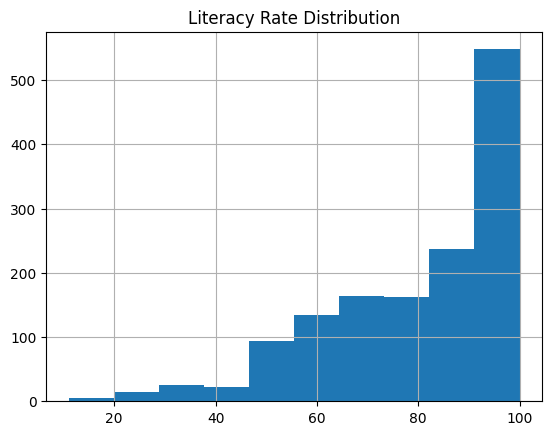

In [ ]:
df_illiteracy["literacy_rate"].hist()
plt.title("Literacy Rate Distribution")
plt.show()

In [ ]:
#boxplot  (to detect outliers)

In [ ]:
import seaborn as sns

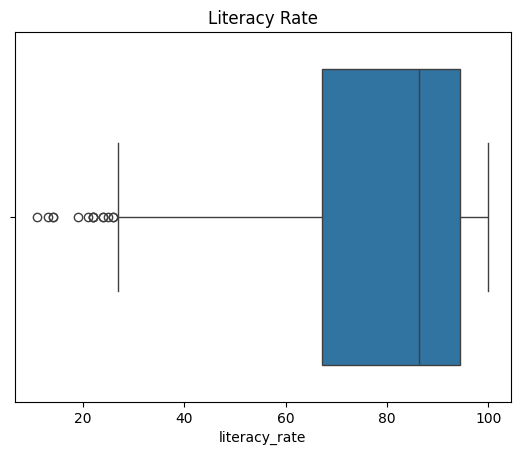

In [ ]:
sns.boxplot(x=df_illiteracy["literacy_rate"])
plt.title("Literacy Rate")
plt.show()

In [ ]:
# bar chat

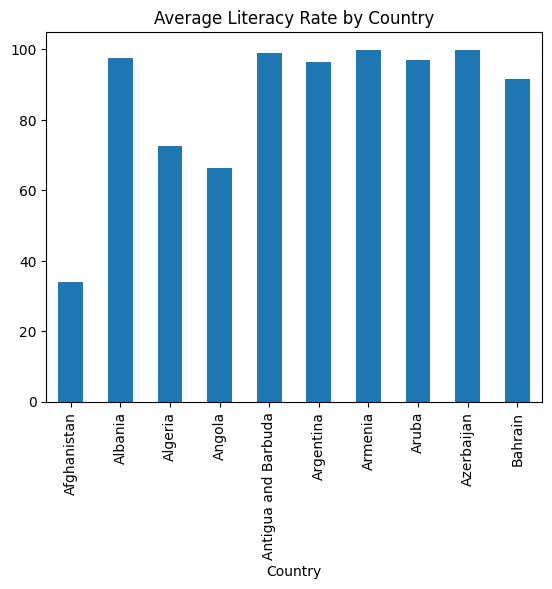

In [ ]:
df_illiteracy.groupby("Country")["literacy_rate"].mean().head(10).plot(kind="bar")
plt.title("Average Literacy Rate by Country")
plt.show()

In [ ]:
#  line plot to find the india's literacy growth rate

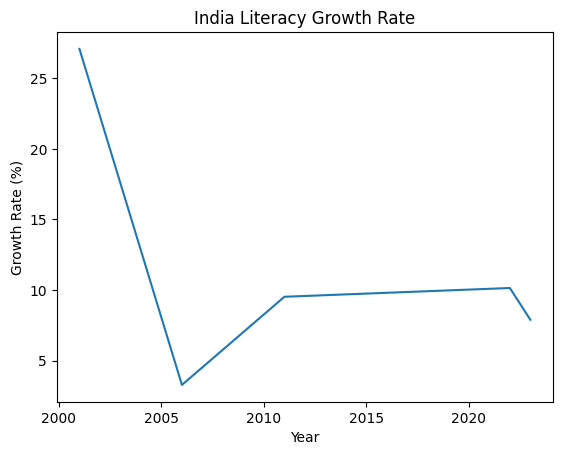

In [ ]:
import matplotlib.pyplot as plt


df_illiteracy = df_illiteracy.sort_values(["Country", "year"])


india = df_illiteracy[df_illiteracy["Country"] == "India"]


growth = india["literacy_rate"].pct_change() * 100


plt.plot(india["year"], growth)
plt.title("India Literacy Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.show()

In [ ]:
# plot find gender literacy gap 5

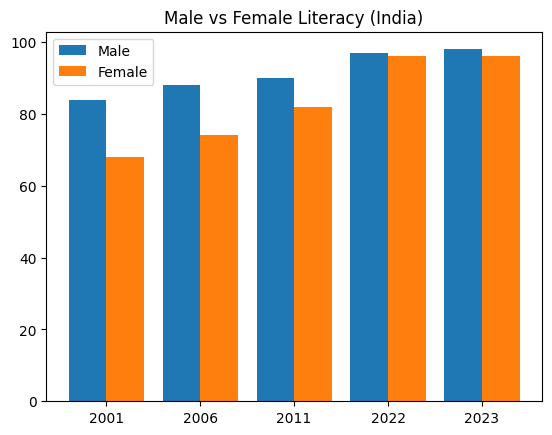

In [ ]:
india = df_literacy[df_literacy["Country"] == "India"]

x = np.arange(len(india))

plt.bar(x-0.2, india["Male_literacy"], 0.4, label="Male")
plt.bar(x+0.2, india["Female_literacy"], 0.4, label="Female")

plt.xticks(x, india["year"])
plt.title("Male vs Female Literacy (India)")
plt.legend()

plt.show()

# **Bivariate**

In [ ]:
# scatter plot

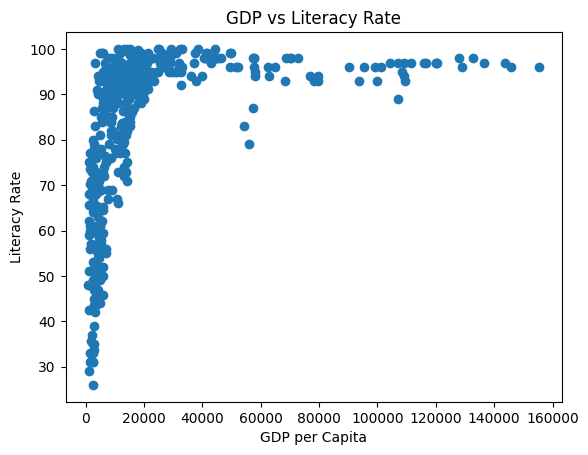

In [ ]:
df = pd.merge(df_gdp_schooling, df_literacy, on=["Country", "year"])

plt.scatter(df["gdp_per_capita"], df["literacy_rate"])

plt.xlabel("GDP per Capita")
plt.ylabel("Literacy Rate")
plt.title("GDP vs Literacy Rate")

plt.show()

In [ ]:
#Line Plot (trend over time)

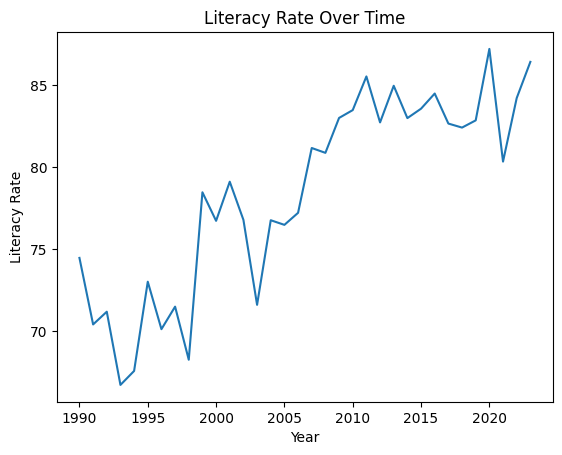

In [ ]:
df_illiteracy.groupby("year")["literacy_rate"].mean().plot()
plt.title("Literacy Rate Over Time")
plt. ylabel("Literacy Rate")
plt.xlabel("Year")
plt.show()

In [ ]:
#correlation Heatmap

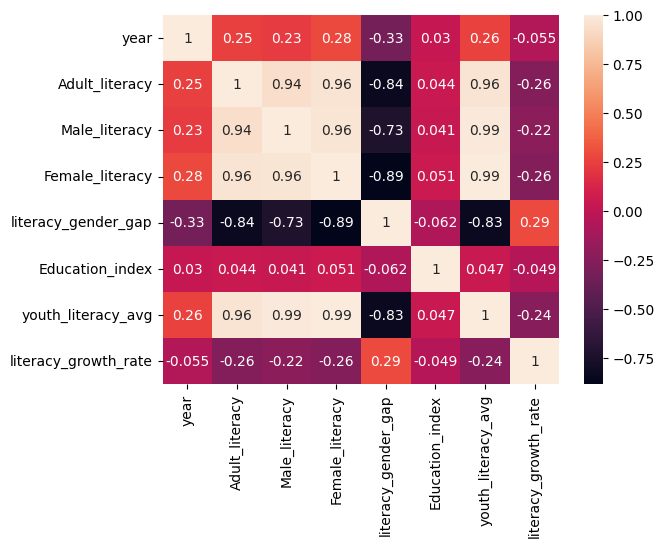

In [ ]:
corr = df_literacy.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
#Literacy vs Illiteracy Trend Over Time india

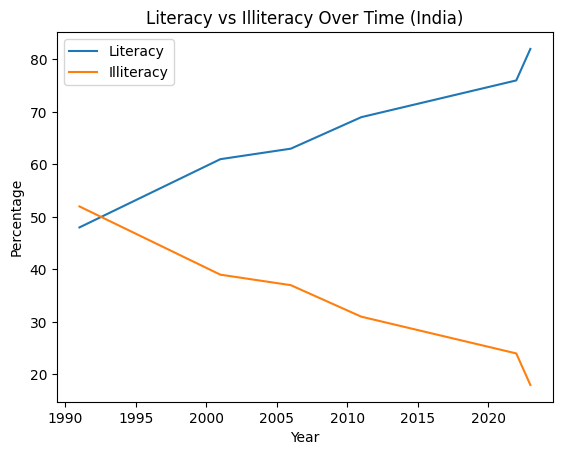

In [ ]:
india = df_illiteracy[df_illiteracy["Country"] == "India"]

plt.plot(india["year"], india["literacy_rate"], label="Literacy")
plt.plot(india["year"], india["illiteracy_rate"], label="Illiteracy")

plt.title("Literacy vs Illiteracy Over Time (India)")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend()

plt.show()

In [ ]:
# top 10 least 10 literacy countries

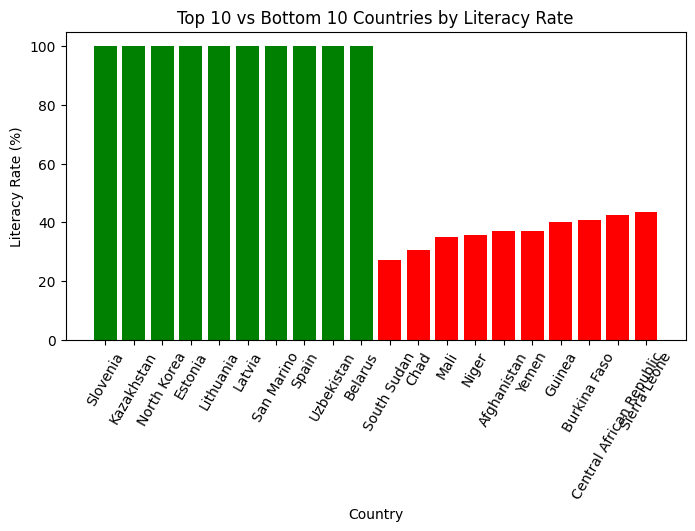

In [ ]:
latest = df_illiteracy.sort_values("year").groupby("Country").tail(1)

top10 = latest.sort_values("literacy_rate", ascending=False).head(10)
bottom10 = latest.sort_values("literacy_rate", ascending=True).head(10)

combined = pd.concat([top10, bottom10])

colors = ["green"]*10 + ["red"]*10

plt.figure(figsize=(8,4))
plt.bar(combined["Country"], combined["literacy_rate"], color=colors)

plt.title("Top 10 vs Bottom 10 Countries by Literacy Rate")
plt.xlabel("Country")
plt.ylabel("Literacy Rate (%)")

plt.xticks(rotation=60)
plt.show()

# **SQL connection**

In [1]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 58.7 MB/s eta 0:00:00


In [2]:
import mysql.connector
conn =mysql.connector.connect(host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
                              user="4G3VCUGCvnHDtM7.root",
                              password="Ti8uXqt2C3cBh9cx",
                              port=4000,
                              database="Global_literacy")
cursor =conn.cursor()

In [ ]:
# create tables

In [ ]:
#  table 1 literacy_rates

In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS literacy_rates(
    Country VARCHAR(100),
    code VARCHAR(10),
    year INT,
    Adult_literacy FLOAT,
    Male_literacy FLOAT,
    Female_literacy FLOAT,
    Region VARCHAR(50),
    literacy_gender_gap FLOAT,
    Education_index FLOAT,
    youth_literacy_avg FLOAT,
    literacy_growth_rate FLOAT,
    India_literacy_growth FLOAT,

    PRIMARY KEY (Country, year)
)
""")

In [ ]:
#table illiteracy_population

In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS illiteracy_population (
    Country VARCHAR(100),
    code VARCHAR(10),
    year INT,
    illiteracy_rate FLOAT,
    literacy_rate FLOAT,
    illiteracy_percentage FLOAT,

    PRIMARY KEY (country, year)
)
""")

In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS gdp_schooling (
    Country VARCHAR(100),
    code VARCHAR(10),
    year INT,
    gdp_per_capita FLOAT,
    Region VARCHAR(50),
    literacy_rate FLOAT,
    avg_yrs_schooling FLOAT,
    population BIGINT,
    gdp_per_schooling_year FLOAT,

    PRIMARY KEY (country, year)
)
""")

In [ ]:
#insert data

In [ ]:
#literacy_rates

In [ ]:
import pandas as pd

In [ ]:
df= pd.read_csv('/content/df_literacy.csv')

In [ ]:
query = """
INSERT INTO literacy_rates (
    Country, code, year, Adult_literacy, Male_literacy, Female_literacy,
    Region, literacy_gender_gap, Education_index,
    youth_literacy_avg, literacy_growth_rate
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""


for _, row in df.iterrows():
    cursor.execute(query, (
        row['Country'],
        row['code'],
        int(row['year']),
        row['Adult_literacy'],
        row['Male_literacy'],
        row['Female_literacy'],
        row['Region'],
        row['literacy_gender_gap'],
        row['Education_index'],
        row['youth_literacy_avg'],
        row['literacy_growth_rate']
    ))


conn.commit()

In [ ]:
# illiteracy_population

In [ ]:
import pandas as pd

df = pd.read_csv("/content/df_illiteracy.csv")

conn =mysql.connector.connect(host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
                              user="4G3VCUGCvnHDtM7.root",
                              password="Ti8uXqt2C3cBh9cx",
                              port=4000,
                              database="Global_literacy")
cursor = conn.cursor()

query = """
INSERT INTO illiteracy_population
(Country, code, year, illiteracy_rate, literacy_rate, illiteracy_percentage)
VALUES (%s, %s, %s, %s, %s, %s)
"""
data = list(df.itertuples(index=False, name=None))

cursor.executemany(query, data)

conn.commit()

print("Data inserted successfully!")

In [ ]:
# gdp_schooling

In [ ]:
import mysql.connector
import pandas as pd

df = pd.read_csv("/content/df_gdp_schooling.csv")

conn =mysql.connector.connect(host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
                              user="4G3VCUGCvnHDtM7.root",
                              password="Ti8uXqt2C3cBh9cx",
                              port=4000,
                              database="Global_literacy")
cursor = conn.cursor()

query = """
INSERT INTO gdp_schooling
(Country, code, year, gdp_per_capita, Region, literacy_rate,
 avg_yrs_schooling, population, gdp_per_schooling_year)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
"""
data = list(df.itertuples(index=False, name=None))

cursor.executemany(query, data)

conn.commit()



# **SQL Query**

In [ ]:
#query 1

In [ ]:
query = """
SELECT Country, Adult_literacy
FROM literacy_rates
WHERE year = 2020
  AND Adult_literacy IS NOT NULL
ORDER BY Adult_literacy DESC
LIMIT 5;
"""
cursor.execute(query)
results = cursor.fetchall()
print("Top 5 Countries by Adult Literacy (2020):\n")
for row in results:
    print(f"Country: {row[0]} \n Adult Literacy Rate: {row[1]}")

Top 5 Countries by Adult Literacy (2020):

Country: Armenia 
 Adult Literacy Rate: 100.0
Country: Europe and Northern America (SDG) 
 Adult Literacy Rate: 98.66912
Country: Europe and Central Asia (WB) 
 Adult Literacy Rate: 98.60383
Country: China 
 Adult Literacy Rate: 97.0
Country: Eastern and South-Eastern Asia (SDG) 
 Adult Literacy Rate: 96.25462


In [ ]:
#query2

In [ ]:
query = """SELECT DISTINCT Country, Female_literacy
FROM literacy_rates
WHERE Female_literacy < 80
  AND Female_literacy IS NOT NULL
ORDER BY Female_literacy ASC;"""

cursor.execute(query)
results = cursor.fetchall()
print("female literacy less than 80:\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"Female_literacy: {row[1]}")



In [ ]:
#query 3

In [ ]:
query ="""SELECT Region, AVG(Adult_literacy) AS avg_Adult_literacy
FROM literacy_rates
WHERE Adult_literacy IS NOT NULL
GROUP BY Region
ORDER BY avg_Adult_literacy DESC;"""

cursor.execute(query)
results = cursor.fetchall()
print("Average Adult Literacy by Region:\n")
for row in results:
    print(f"Region: {row[0]}")
    print(f"Average Adult Literacy: {row[1]}")


In [ ]:
# query 4 illiteracy_population

In [ ]:
query= """SELECT Country, illiteracy_percentage
FROM illiteracy_population
WHERE year = 2000
  AND illiteracy_percentage > 20
ORDER BY illiteracy_percentage DESC;"""

cursor.execute(query)
results = cursor.fetchall()
print("countries with more than 20% illiteracy rate in 2000:\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"Illiteracy Percentage: {row[1]}")



In [ ]:
#query 5

In [ ]:
query = """SELECT year, illiteracy_percentage
FROM illiteracy_population
WHERE country = 'India'
  AND year BETWEEN 2000 AND 2020
ORDER BY year;"""

cursor.execute(query)
results = cursor.fetchall()
print("Illiteracy percentage of India")
for row in results:
    print(f"Year: {row[0]}")
    print(f"Illiteracy Percentage: {row[1]}")

In [ ]:
# query 6

In [ ]:
query ="""SELECT Country, illiteracy_rate
FROM illiteracy_population
WHERE year = (SELECT MAX(year) FROM illiteracy_population)
ORDER BY illiteracy_rate DESC
LIMIT 10;"""

cursor.execute(query)
results = cursor.fetchall()
print("Top 10 countries with  largest illiteracy rate" )
for row in results:
    print(f"Country: {row[0]}")
    print(f"Illiteracy Rate: {row[1]}")

In [ ]:
# query7

In [ ]:
query ="""SELECT Country, avg_yrs_schooling, gdp_per_capita
FROM gdp_schooling
WHERE avg_yrs_schooling > 7
  AND gdp_per_capita < 5000;"""

cursor.execute(query)
results = cursor.fetchall()
print("Countries with greater than 7 years of schooling and a GDP per capita less than 5000:\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"Average Years of Schooling: {row[1]}")
    print(f"GDP per Capita: {row[2]}")

In [ ]:
#query 8

In [ ]:
query ="""SELECT country,gdp_per_schooling_year
from gdp_schooling
where year = 2020
and gdp_per_schooling_year IS NOT NULL
order by gdp_per_schooling_year;"""


cursor.execute(query)
results = cursor.fetchall()
print("Ranking Countries by gdp per schooling year in 2020:\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"GDP per schooling_year: {row[1]}")



In [ ]:
#query9

In [ ]:
query ="""SELECT year,
       AVG(avg_yrs_schooling) AS global_avg_schooling
FROM gdp_schooling
WHERE avg_yrs_schooling IS NOT NULL
GROUP BY year
ORDER BY year;"""


cursor.execute(query)
results = cursor.fetchall()
print("Global average schooling years per year:\n")
for row in results:
    print(f"year: {row[0]}")
    print(f" Global Average schooling: {row[1]}")

In [ ]:
# join queries query 10

In [ ]:
query ="""SELECT g.Country, g.gdp_per_capita, g.avg_yrs_schooling
FROM gdp_schooling g
WHERE g.year = 2020
  AND g.avg_yrs_schooling < 6
  AND g.gdp_per_capita IS NOT NULL
ORDER BY g.gdp_per_capita DESC
LIMIT 10;"""

cursor.execute(query)
results = cursor.fetchall()
print("Top 10 countries with highest GDP and lowest average schooling:\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"GDP per Capita: {row[1]}")
    print(f"Average Years of Schooling: {row[2]}")

In [ ]:
#query 11

In [ ]:
query ="""SELECT i.country, i.illiteracy_rate, g.avg_yrs_schooling
FROM illiteracy_population i
JOIN gdp_schooling g
  ON i.country = g.country AND i.year = g.year
WHERE g.avg_yrs_schooling > 10
  ORDER BY i.illiteracy_rate DESC;"""

cursor.execute(query)
results = cursor.fetchall()
print("Countries with high illiteracy population and more than 10 avg year schooling :\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"Illiteracy Rate: {row[1]}")
    print(f"Average Years of Schooling: {row[2]}")


In [ ]:
# query 12

In [ ]:
query = """SELECT i.Country ,i.year, i.literacy_rate, g.gdp_per_capita
FROM illiteracy_population i
JOIN gdp_schooling g
  ON i.country = g.country AND i.year = g.year
WHERE i.country = 'India'
  AND i.year >= 2000
ORDER BY i.year;"""


cursor.execute(query)
results = cursor.fetchall()
print("Literacy Rates vs GDP Growth  :\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"year: {row[1]}")
    print(f"Illiteracy Rate: {row[2]}")
    print(f"GDP per Capita: {row[3]}")

In [ ]:
# query 13

In [ ]:
query ="""SELECT l.country,
       l.Male_literacy,
       l.Female_literacy,
       (l.Male_literacy - l.Female_literacy) AS gender_gap,
       g.gdp_per_capita
FROM literacy_rates l
JOIN gdp_schooling g
  ON l.country = g.country AND l.year = g.year
WHERE l.year = 2020
  AND g.gdp_per_capita > 30000
ORDER BY gender_gap DESC;"""


cursor.execute(query)
results = cursor.fetchall()
print("Male and Female literacy difference and gdp above 30000  :\n")
for row in results:
    print(f"Country: {row[0]}")
    print(f"Male literacy: {row[1]}")
    print(f"Female_literacy: {row[2]}")
    print(f"gender_gap: {row[3]}")
    print(f"GDP per Capita: {row[4]}")



# **Streamlit**

In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

In [ ]:
!pip install streamlit-option-menu

In [9]:
%%writefile literacy.py

import streamlit as st
from streamlit_option_menu import option_menu
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



df_illiteracy = pd.read_csv("df_illiteracy.csv")
df_literacy = pd.read_csv("df_literacy.csv")
df_gdp_schooling = pd.read_csv("df_gdp_schooling.csv")


st.title("📊Global Literacy & Education Trends")

import mysql.connector
conn =mysql.connector.connect(host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
                              user="4G3VCUGCvnHDtM7.root",
                              password="Ti8uXqt2C3cBh9cx",
                              port=4000,
                              database="Global_literacy")
cursor = conn.cursor()
questions=["1.Get top 5 countries with highest adult literacy in 2020",
          "2.Find countries where female youth literacy < 80%",
          "3.Average adult literacy per continent (owid region)",
          "4.Countries with illiteracy % > 20% in 2000",
          "5.Trend of illiteracy % for India (2000–2020)",
          "6.Top 10 countries with largest illiterate population in the last year",
          "7.Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000",
          "8.Rank countries by GDP per schooling for the year 2020",
          "9.Find global average schooling years per year",
          "10.List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6)",
          "11.Show countries where the illiterate population is high despite having more than 10 average years of schooling",
          "12.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years",
          "13.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years"]
Chart =["1.histogram for literacy rate distribution",
      "2.boxplot(to detect outliers of literacy rate)",
      "3.bar chat average literacy rate",
      "4.line plot to find the india's literacy growth rate",
      "5.plot find gender literacy gap",
      "6.scatter plot for Gdp vs Literacy rate",
      "7.Line Plot (trend over time)",
      "8.correlation Heatmap",
      "9.Literacy vs Illiteracy Trend Over Time india",
      "10.top 10 least 10 literacy countries"]
st.sidebar.title("📌 Literacy Trends")
page = st.sidebar.radio(
    "Go to",
    [
        "SQL Query Executor",
        "EDA Visualizations",
        "Country Profile Page"
    ]
)

if page == "SQL Query Executor":
    query_selected=st.selectbox("Select the Query",questions)
    btn = st.button("Run Query")
    if btn:
            if query_selected == "1.Get top 5 countries with highest adult literacy in 2020":
                query = """
                            SELECT Country, Adult_literacy
                            FROM literacy_rates
                            WHERE year = 2020
                            AND Adult_literacy IS NOT NULL
                            ORDER BY Adult_literacy DESC
                            LIMIT 5;
                            """

                df = pd.read_sql(query, conn)
                st.success("Query executed successfully 1")
                st.dataframe(df,use_container_width=True)

                st.subheader("📊 Charts")

                fig, ax = plt.subplots()
                ax.bar(df["Country"], df["Adult_literacy"])

                ax.set_xlabel("Country")
                ax.set_ylabel("Adult Literacy")
                ax.set_title("Top 5 Countries by Adult Literacy (2020)")

                plt.xticks(rotation=25)
                st.pyplot(fig)
            elif query_selected == "2.Find countries where female youth literacy < 80%":
                    query ="""SELECT DISTINCT Country, Female_literacy
                                FROM literacy_rates
                                WHERE Female_literacy < 80
                                AND Female_literacy IS NOT NULL
                                ORDER BY Female_literacy ASC;"""

                    df = pd.read_sql(query, conn)
                    st.success("Query executed successfully 2")
                    st.dataframe(df,use_container_width=True)

                    st.subheader("📊 Charts")

                    fig, ax = plt.subplots()

                    ax.bar(df["Country"], df["Female_literacy"])

                    ax.set_xlabel("Country")
                    ax.set_ylabel("Female Literacy")
                    ax.set_title("Countries with Female Literacy < 80%")

                    plt.xticks(rotation=25)

                    st.pyplot(fig)
            elif query_selected == "3.Average adult literacy per continent (owid region)":
                    query="""SELECT Region, AVG(Adult_literacy) AS avg_Adult_literacy
                                FROM literacy_rates
                                WHERE Adult_literacy IS NOT NULL
                                GROUP BY Region
                                ORDER BY avg_Adult_literacy DESC;"""

                    df = pd.read_sql(query, conn)
                    st.success("Query executed successfully 3")
                    st.dataframe(df,use_container_width=True)

                    st.subheader("📊 Charts")
                    fig, ax = plt.subplots()

                    ax.bar(df["Region"], df["avg_Adult_literacy"])

                    ax.set_xlabel("Region")
                    ax.set_ylabel("Average Adult Literacy")
                    ax.set_title("Average Adult Literacy per Region")

                    plt.xticks(rotation=45)

                    st.pyplot(fig)
            elif query_selected == "4.Countries with illiteracy % > 20% in 2000":
                 query= """SELECT Country, illiteracy_percentage
                            FROM illiteracy_population
                            WHERE year = 2000
                            AND illiteracy_percentage > 20
                            ORDER BY illiteracy_percentage DESC;"""
                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 4")
                 st.dataframe(df,use_container_width=True)

                 st.subheader("📊 Charts")
                 fig, ax = plt.subplots()

                 ax.bar(df["Country"], df["illiteracy_percentage"])

                 ax.set_xlabel("Country")
                 ax.set_ylabel("Illiteracy %")
                 ax.set_title("Countries with Illiteracy > 20% (Year 2000)")

                 plt.xticks(rotation=45)

                 st.pyplot(fig)

            elif query_selected == "5.Trend of illiteracy % for India (2000–2020)":
                 query = """SELECT year, illiteracy_percentage
                            FROM illiteracy_population
                            WHERE country = 'India'
                            AND year BETWEEN 2000 AND 2020
                            ORDER BY year;"""

                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 5")
                 st.dataframe(df,use_container_width=True)
                 st.subheader("📊 Charts")
                 fig, ax = plt.subplots()

                 ax.plot(df["year"], df["illiteracy_percentage"], marker='o')

                 ax.set_xlabel("Year")
                 ax.set_ylabel("Illiteracy %")
                 ax.set_title("Trend of Illiteracy % in India (2000–2020)")

                 st.pyplot(fig)
            elif query_selected == "6.Top 10 countries with largest illiterate population in the last year":
                 query ="""SELECT Country, illiteracy_rate
                            FROM illiteracy_population
                            WHERE year = (SELECT MAX(year) FROM illiteracy_population)
                            ORDER BY illiteracy_rate DESC
                            LIMIT 10;"""
                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 6")
                 st.dataframe(df,use_container_width=True)
                 st.subheader("📊 Charts")
                 fig, ax = plt.subplots()

                 ax.barh(df["Country"], df["illiteracy_rate"])

                 ax.set_xlabel("Illiteracy Rate")
                 ax.set_ylabel("Country")
                 ax.set_title("Top 10 Countries by Illiteracy Rate (Latest Year)")


                 ax.invert_yaxis()

                 st.pyplot(fig)
            elif query_selected == "7.Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000":
                 query ="""SELECT Country, avg_yrs_schooling, gdp_per_capita
                            FROM gdp_schooling
                            WHERE avg_yrs_schooling > 7
                            AND gdp_per_capita < 5000;"""

                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 7")
                 st.dataframe(df,use_container_width=True)
                 st.subheader("📊 Charts")

                 fig, ax = plt.subplots()

                 ax.scatter(df["avg_yrs_schooling"], df["gdp_per_capita"])

                 ax.set_xlabel("Average Years of Schooling")
                 ax.set_ylabel("GDP per Capita")
                 ax.set_title("Schooling vs GDP (Selected Countries)")

                 st.pyplot(fig)
            elif query_selected == "8.Rank countries by GDP per schooling for the year 2020":
                query ="""SELECT country,gdp_per_schooling_year
                            from gdp_schooling
                            where year = 2020
                            and gdp_per_schooling_year IS NOT NULL
                            order by gdp_per_schooling_year
                            limit 10;"""

                df = pd.read_sql(query, conn)
                st.success("Query executed successfully 8")
                st.dataframe(df,use_container_width=True)
                st.subheader("📊 Charts")


                fig, ax = plt.subplots(figsize=(10, 6))

                ax.barh(df["country"], df["gdp_per_schooling_year"])

                ax.set_xlabel("GDP per Schooling Year")
                ax.set_ylabel("Country")
                ax.set_title("GDP per Schooling Year by Country (2020)")


                ax.invert_yaxis()

                st.pyplot(fig)
            elif query_selected == "9.Find global average schooling years per year":
                 query ="""SELECT year,
                            AVG(avg_yrs_schooling) AS global_avg_schooling
                            FROM gdp_schooling
                            WHERE avg_yrs_schooling IS NOT NULL
                            GROUP BY year
                            ORDER BY year;"""

                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 9")
                 st.dataframe(df,use_container_width=True)
                 st.subheader("📊 Charts")
                 fig, ax = plt.subplots()

                 ax.plot(df["year"], df["global_avg_schooling"], marker='o')

                 ax.set_xlabel("Year")
                 ax.set_ylabel("Global Avg Schooling Years")
                 ax.set_title("Global Average Schooling Years per Year")

                 st.pyplot(fig)
            elif query_selected == "10.List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6)":
                 query ="""SELECT g.Country, g.gdp_per_capita, g.avg_yrs_schooling
                            FROM gdp_schooling g
                            WHERE g.year = 2020
                            AND g.avg_yrs_schooling < 6
                            AND g.gdp_per_capita IS NOT NULL
                            ORDER BY g.gdp_per_capita DESC
                            LIMIT 10;"""
                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 10")
                 st.dataframe(df,use_container_width=True)
                 st.subheader("📊 Charts")
                 x = np.arange(len(df["Country"]))

                 fig, ax = plt.subplots(figsize=(10, 6))

                 ax.bar(x - 0.2, df["gdp_per_capita"], width=0.4, label="GDP per Capita")
                 ax.bar(x + 0.2, df["avg_yrs_schooling"], width=0.4, label="Avg Years Schooling")

                 ax.set_xticks(x)
                 ax.set_xticklabels(df["Country"], rotation=45)

                 ax.set_xlabel("Country")
                 ax.set_ylabel("Values")
                 ax.set_title("GDP vs Schooling (Top 10 Countries)")

                 ax.legend()

                 st.pyplot(fig)
            elif query_selected =="11.Show countries where the illiterate population is high despite having more than 10 average years of schooling":
                  query ="""SELECT i.country, i.illiteracy_rate, g.avg_yrs_schooling
                            FROM illiteracy_population i
                            JOIN gdp_schooling g
                            ON i.country = g.country AND i.year = g.year
                            WHERE g.avg_yrs_schooling > 10
                            ORDER BY i.illiteracy_rate DESC;"""
                  df = pd.read_sql(query, conn)
                  st.success("Query executed successfully 11")
                  st.dataframe(df,use_container_width=True)
                  st.subheader("📊 Charts")

                  df = df.sort_values(by="illiteracy_rate", ascending=True)

                  fig, ax = plt.subplots(figsize=(10, 6))

                  ax.barh(df["country"], df["illiteracy_rate"])

                  ax.set_xlabel("Illiteracy Rate")
                  ax.set_ylabel("Country")
                  ax.set_title("Countries with High Illiteracy despite High Schooling")

                  st.pyplot(fig)
            elif query_selected =="12.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years":
                 query = """SELECT i.Country ,i.year, i.literacy_rate, g.gdp_per_capita
                            FROM illiteracy_population i
                            JOIN gdp_schooling g
                            ON i.country = g.country AND i.year = g.year
                            WHERE i.country = 'India'
                            AND i.year >= 2000
                            ORDER BY i.year;"""

                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 12")
                 st.dataframe(df,use_container_width=True)
                 st.subheader("📊 Charts")
                 fig, ax1 = plt.subplots()

                 chart_data = df.set_index("year")[["literacy_rate", "gdp_per_capita"]]
                 st.line_chart(chart_data)
            elif query_selected =="13.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years":
                 query ="""SELECT l.country,
                            l.Male_literacy,
                            l.Female_literacy,
                            (l.Male_literacy - l.Female_literacy) AS gender_gap,
                            g.gdp_per_capita
                        FROM literacy_rates l
                        JOIN gdp_schooling g
                        ON l.country = g.country AND l.year = g.year
                        WHERE l.year = 2020
                        AND g.gdp_per_capita > 30000
                        ORDER BY gender_gap DESC;"""
                 df = pd.read_sql(query, conn)
                 st.success("Query executed successfully 13")
                 st.dataframe(df,use_container_width=True)
                 st.subheader("📊 Charts")


                 chart_data = df.set_index("country")[["Male_literacy", "Female_literacy"]]
                 st.bar_chart(chart_data)


elif page == "EDA Visualizations":
    st.title("EDA Visualizations")
    query_selected=st.selectbox("Select the chart",Chart)
    btn = st.button("Run chart")
    if btn:
        if query_selected == "1.histogram for literacy rate distribution":

            fig, ax = plt.subplots()
            df_illiteracy["literacy_rate"].hist(ax=ax)
            plt.title("Literacy Rate Distribution")
            st.pyplot(fig)
        elif query_selected == "2.boxplot(to detect outliers of literacy rate)":
            fig, ax = plt.subplots()
            sns.boxplot(x=df_illiteracy["literacy_rate"], ax=ax)

            ax.set_title("Literacy Rate")
            st.pyplot(fig)
        elif query_selected == "3.bar chat average literacy rate":
            fig, ax = plt.subplots()
            data = df_illiteracy.groupby("Country")["literacy_rate"].mean().head(10)
            data.plot(kind="bar", ax=ax)

            ax.set_title("Average Literacy Rate by Country")
            ax.set_xlabel("Country")
            ax.set_ylabel("Literacy Rate")
            st.pyplot(fig)

        elif query_selected ==  "4.line plot to find the india's literacy growth rate":
            fig, ax = plt.subplots()
            df_illiteracy = df_illiteracy.sort_values(["Country", "year"])
            india = df_illiteracy[df_illiteracy["Country"] == "India"]
            growth = india["literacy_rate"].pct_change() * 100
            ax.plot(india["year"], growth)
            ax.set_title("India Literacy Growth Rate")
            ax.set_xlabel("Year")
            ax.set_ylabel("Growth Rate (%)")
            st.pyplot(fig)

        elif query_selected =="5.plot find gender literacy gap":
            df = pd.merge(df_gdp_schooling, df_literacy, on=["Country", "year"])
            fig, ax = plt.subplots()
            india = df_literacy[df_literacy["Country"] == "India"]
            x = np.arange(len(india))

            ax.bar(x - 0.2, india["Male_literacy"], 0.4, label="Male")
            ax.bar(x + 0.2, india["Female_literacy"], 0.4, label="Female")

            ax.set_xticks(x)
            ax.set_xticklabels(india["year"], rotation=45)

            ax.set_title("Male vs Female Literacy (India)")
            ax.set_xlabel("Year")
            ax.set_ylabel("Literacy Rate")
            ax.legend()
            st.pyplot(fig)
        elif query_selected =="6.scatter plot for Gdp vs Literacy rate":
            fig, ax = plt.subplots()

            df = pd.merge(
                df_gdp_schooling,
                df_literacy,
                on=["Country", "year"]
            )


            ax.scatter(df["gdp_per_capita"], df["literacy_rate"])

            ax.set_xlabel("GDP per Capita")
            ax.set_ylabel("Literacy Rate")
            ax.set_title("GDP vs Literacy Rate")
            st.pyplot(fig)
        elif query_selected =="7.Line Plot (trend over time)":
               fig, ax = plt.subplots()
               trend = df_illiteracy.groupby("year")["literacy_rate"].mean()

               ax.plot(trend.index, trend.values)

               ax.set_title("Literacy Rate Over Time")
               ax.set_xlabel("Year")
               ax.set_ylabel("Literacy Rate")
               st.pyplot(fig)
        elif query_selected =="8.correlation Heatmap":
             fig, ax = plt.subplots()
             corr = df_literacy.corr(numeric_only=True)
             sns.heatmap(corr, annot=True, ax=ax)
             ax.set_title("Correlation Heatmap")
             st.pyplot(fig)
        elif query_selected =="9.Literacy vs Illiteracy Trend Over Time india":
             fig, ax = plt.subplots()
             india = df_illiteracy[df_illiteracy["Country"] == "India"]

             india = india.sort_values("year")

             ax.plot(india["year"], india["literacy_rate"], label="Literacy")
             ax.plot(india["year"], india["illiteracy_rate"], label="Illiteracy")

             ax.set_title("Literacy vs Illiteracy Over Time (India)")
             ax.set_xlabel("Year")
             ax.set_ylabel("Percentage")
             ax.legend()
             st.pyplot(fig)
        elif query_selected =="10.top 10 least 10 literacy countries":
             fig, ax = plt.subplots()
             latest = df_illiteracy.sort_values("year").groupby("Country").tail(1)

             top10 = latest.sort_values("literacy_rate", ascending=False).head(10)
             bottom10 = latest.sort_values("literacy_rate", ascending=True).head(10)

             combined = pd.concat([top10, bottom10])

             colors = ["green"] * 10 + ["red"] * 10

             ax.bar(combined["Country"], combined["literacy_rate"], color=colors)

             ax.set_title("Top 10 vs Bottom 10 Countries by Literacy Rate")
             ax.set_xlabel("Country")
             ax.set_ylabel("Literacy Rate (%)")
             ax.tick_params(axis='x', rotation=60)

             st.pyplot(fig)


elif page == "Country Profile Page":
    st.title("Country Profile Page")
    countries = df_literacy["Country"].unique()
    selected_country = st.selectbox("Select Country", countries)


    lit = df_literacy[df_literacy["Country"] == selected_country]
    illit = df_illiteracy[df_illiteracy["Country"] == selected_country]
    gdp = df_gdp_schooling[df_gdp_schooling["Country"] == selected_country]


    # Literacy vs Illiteracy

    fig1, ax1 = plt.subplots()
    ax1.plot(illit["year"], illit["literacy_rate"], label="Literacy")
    ax1.plot(illit["year"], illit["illiteracy_rate"], label="Illiteracy")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Percentage")
    ax1.legend()
    ax1.set_title("Literacy vs Illiteracy")

    st.pyplot(fig1)


    # GDP Trend
    fig2, ax2 = plt.subplots()
    ax2.plot(gdp["year"], gdp["gdp_per_capita"])
    ax2.set_title("GDP per Capita")

    st.pyplot(fig2)

    # Male vs Female Literacy

    if "Male_literacy" in lit.columns:
        fig3, ax3 = plt.subplots()
        ax3.plot(lit["year"], lit["Male_literacy"], label="Male")
        ax3.plot(lit["year"], lit["Female_literacy"], label="Female")
        ax3.legend()
        ax3.set_title("Male vs Female Literacy")

        st.pyplot(fig3)
































Overwriting literacy.py


In [6]:
!streamlit run /content/literacy.py &>/content/logs.txt &

In [7]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://halo-soft-freight-sharon.trycloudflare.com
